Iter 00 | rho=0.5248 | tr(Q)=0.614 | MSE=0.6275
Iter 01 | rho=0.5042 | tr(Q)=0.780 | MSE=0.4738
Iter 02 | rho=0.5228 | tr(Q)=0.950 | MSE=0.4292
Iter 03 | rho=0.5619 | tr(Q)=1.094 | MSE=0.4158
Iter 04 | rho=0.6060 | tr(Q)=1.218 | MSE=0.4126
Iter 05 | rho=0.6507 | tr(Q)=1.340 | MSE=0.4128
Iter 06 | rho=0.6996 | tr(Q)=1.460 | MSE=0.4190
Iter 07 | rho=0.7307 | tr(Q)=1.536 | MSE=0.4253
Iter 08 | rho=0.7383 | tr(Q)=1.577 | MSE=0.4260
Iter 09 | rho=0.7346 | tr(Q)=1.614 | MSE=0.4246
Iter 10 | rho=0.7265 | tr(Q)=1.656 | MSE=0.4230
Iter 11 | rho=0.7168 | tr(Q)=1.706 | MSE=0.4212
Iter 12 | rho=0.7087 | tr(Q)=1.770 | MSE=0.4189
Iter 13 | rho=0.7096 | tr(Q)=1.859 | MSE=0.4162
Iter 14 | rho=0.7407 | tr(Q)=1.988 | MSE=0.4136
Iter 15 | rho=0.8524 | tr(Q)=2.139 | MSE=0.4134
Iter 16 | rho=1.1316 | tr(Q)=2.221 | MSE=0.4155
Iter 17 | rho=1.7086 | tr(Q)=2.208 | MSE=0.4164
Iter 18 | rho=2.4442 | tr(Q)=2.182 | MSE=0.4164
Iter 19 | rho=2.4442 | tr(Q)=2.182 | MSE=0.4164
Iter 20 | rho=2.4442 | tr(Q)=2.182 | MSE

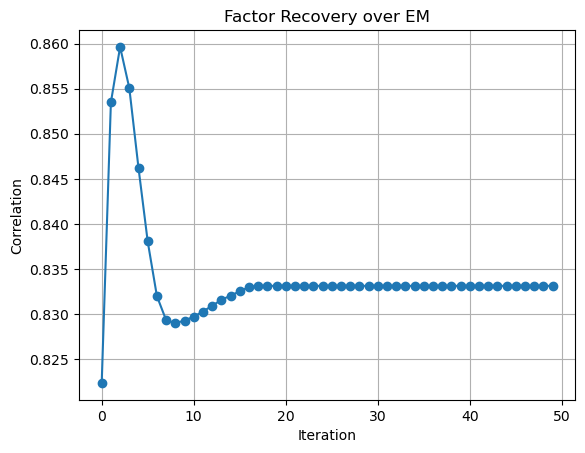

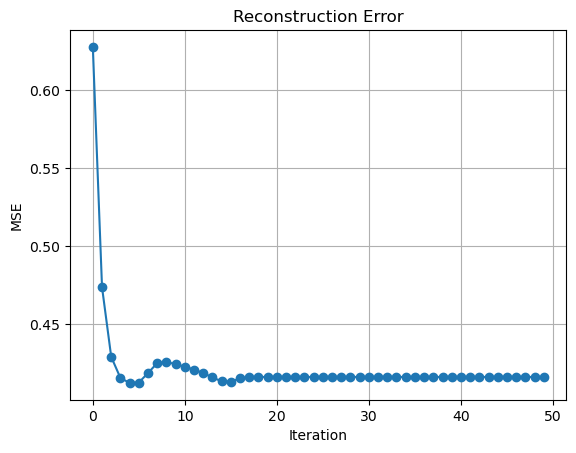

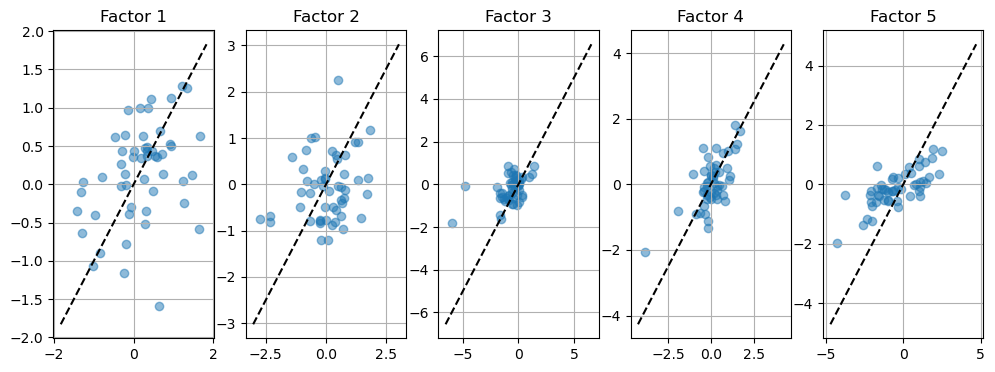

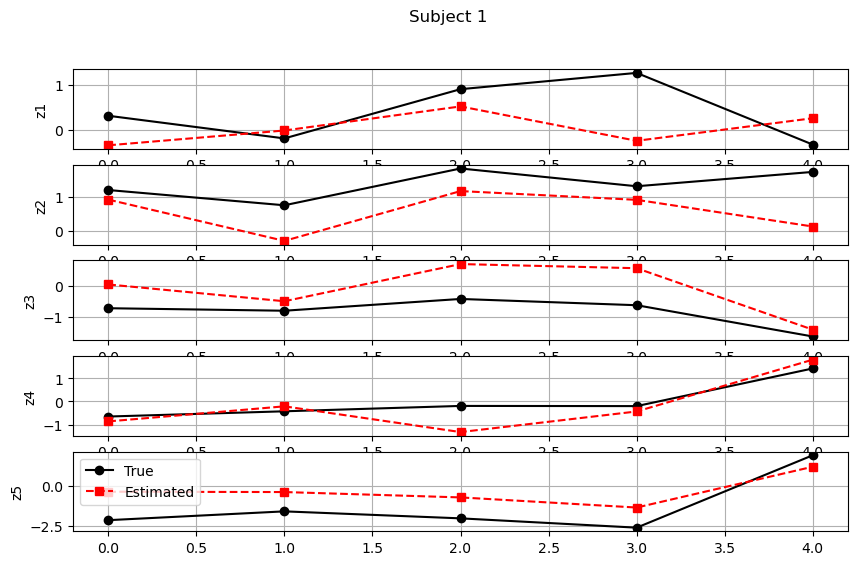

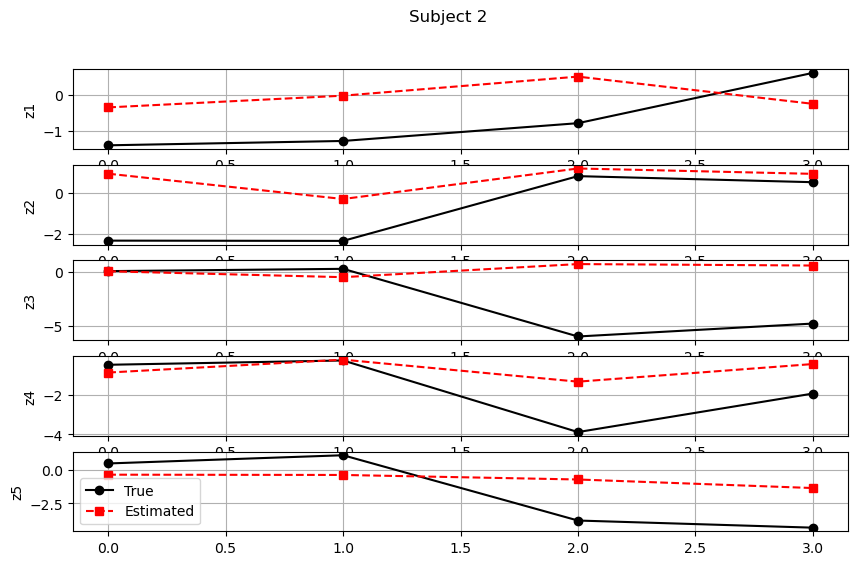

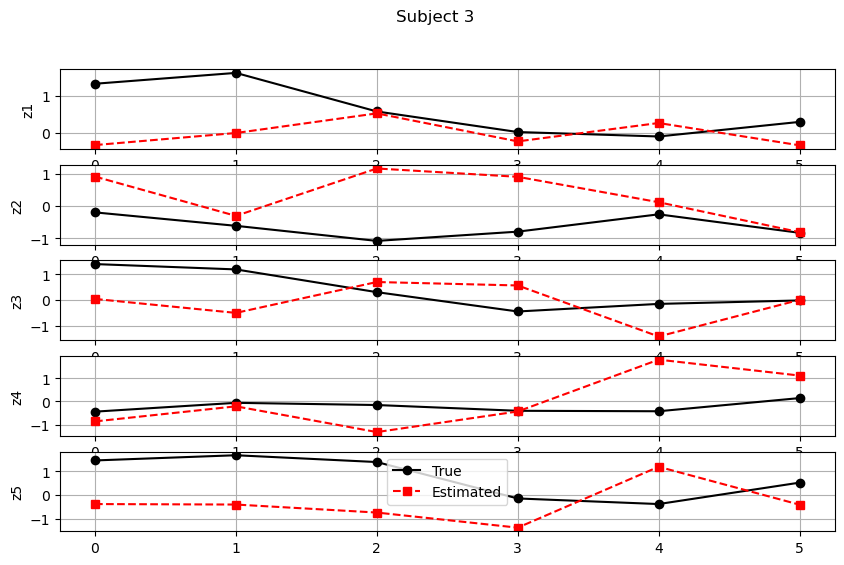

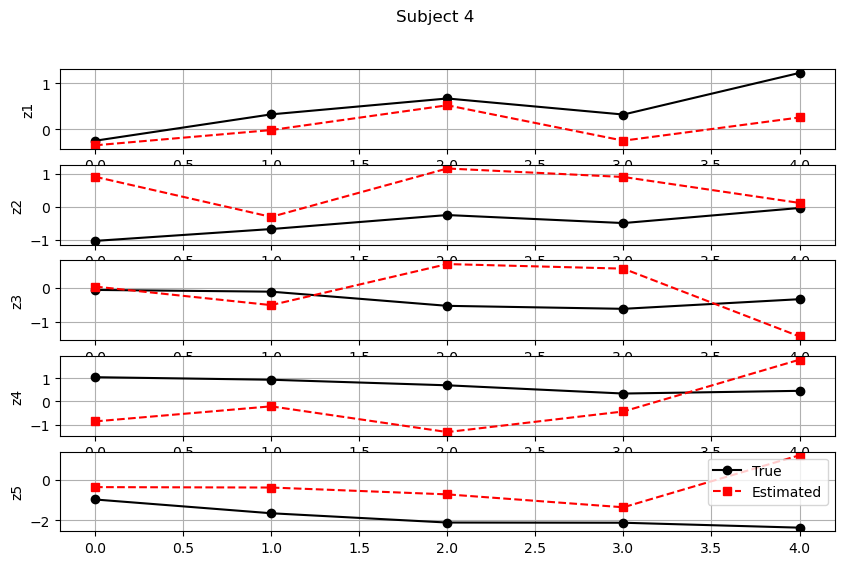

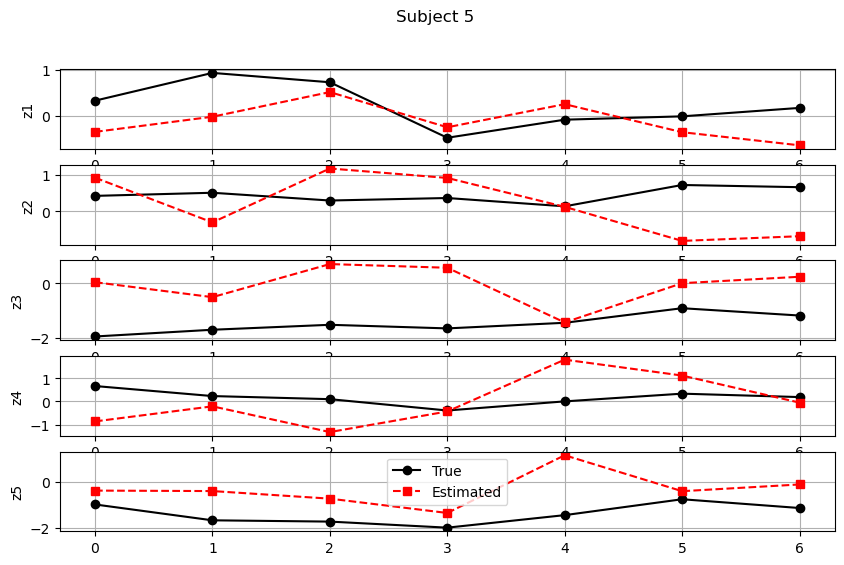

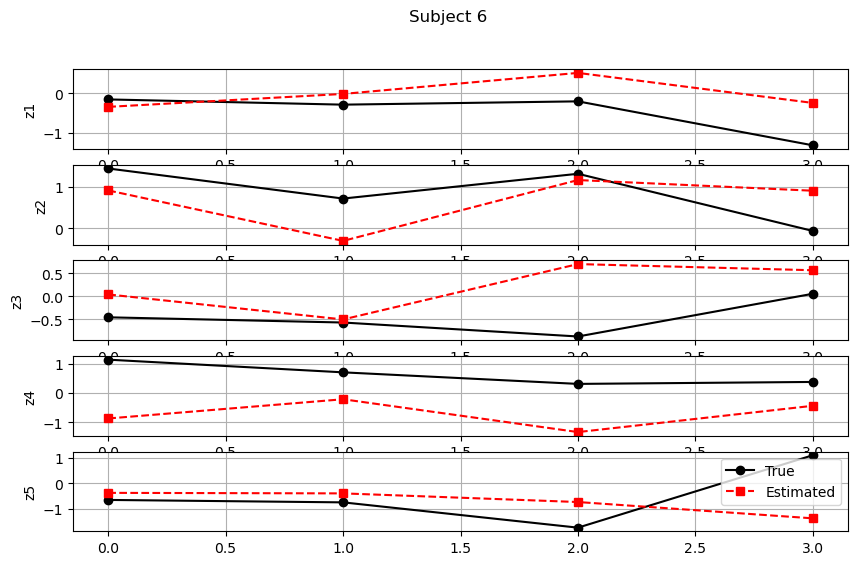

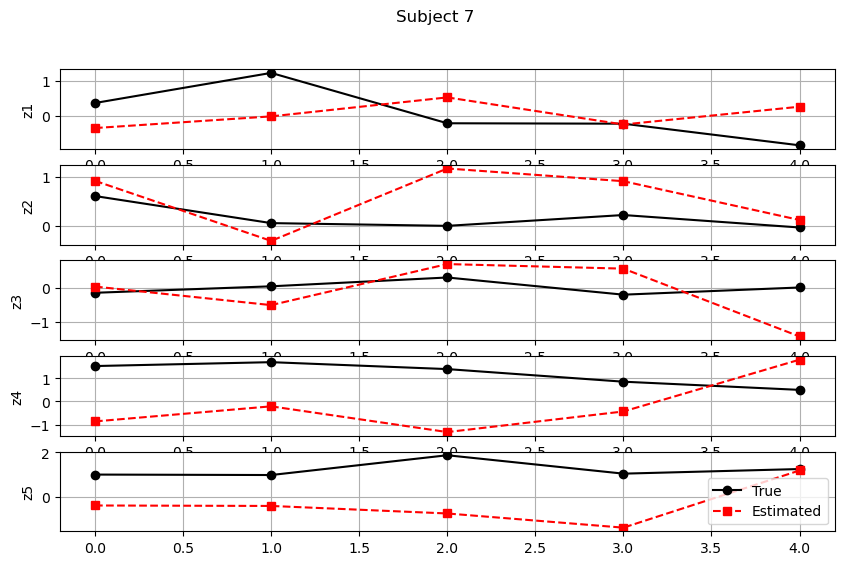

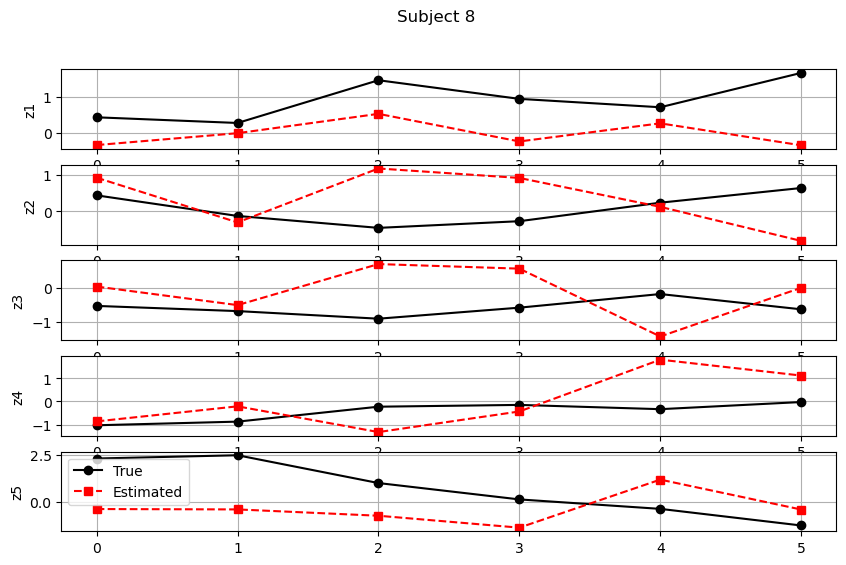

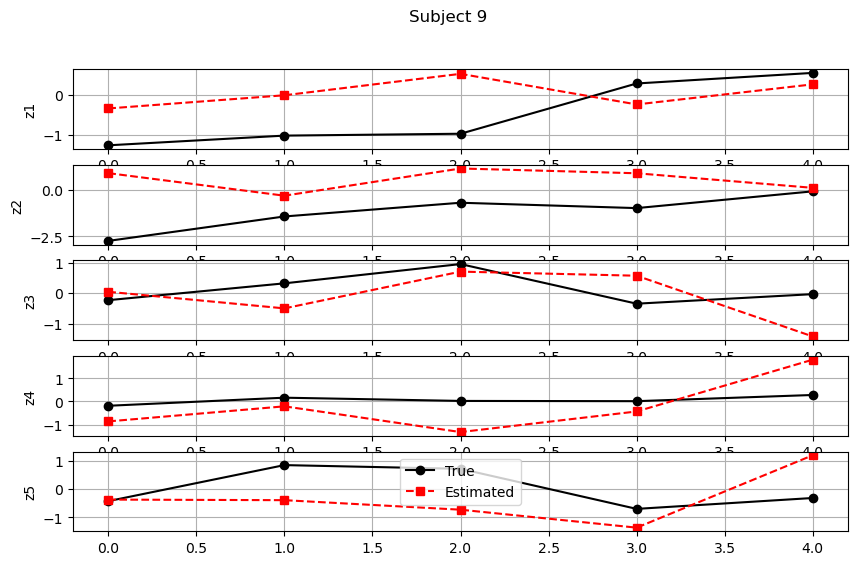

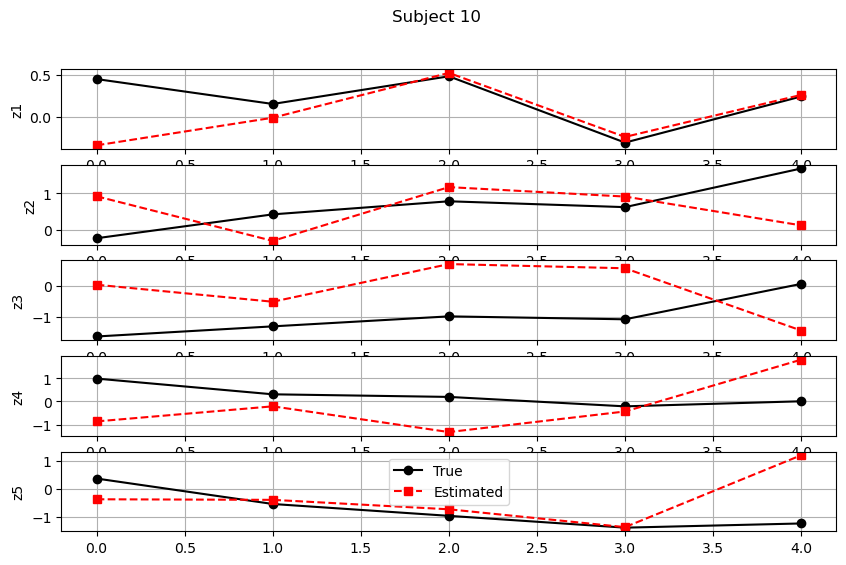

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ============================================================
# 1. DATA GENERATION
# ============================================================

def simulate_ou_dfa(
    n_subjects=10,
    T_list=(5,4,6,5,7,4,5,6,5,5),
    p=20,
    k=5,
    rho_mean=0.05,
    rho_sd=0.03,
    Q_scale=0.3,
    Psi_scale=0.5,
    sparsity=0.7,
    shock_prob=0.05,
    shock_scale=3.0,
    seed=42,
):
    rng = np.random.default_rng(seed)

    # ----- Loadings -----
    Lambda = rng.normal(size=(p, k))
    Lambda *= rng.uniform(size=(p, k)) > sparsity

    if k > 1:
        Lambda[:, 1] += 0.8 * Lambda[:, 0]

    Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)

    # ----- Latent dynamics -----
    rho_true = np.abs(rng.normal(rho_mean, rho_sd, size=k))
    R = rng.normal(size=(k, k))
    Q_true = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 10.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(size=k)

        for t in range(1, T):
            A = np.diag(np.exp(-rho_true * dt[t-1]))
            z[t] = A @ z[t-1] + rng.multivariate_normal(np.zeros(k), Q_true)

            if rng.uniform() < shock_prob:
                z[t] += rng.normal(0, shock_scale, size=k)

        Psi_diag = Psi_scale * rng.lognormal(0.0, 0.5, size=p)
        y = z @ Lambda.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda, rho_true, Q_true, dts_all


# ============================================================
# 2. KALMAN FILTER + RTS SMOOTHER
# ============================================================

def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)

    m_filt = np.zeros((T, k))
    P_filt = np.zeros((T, k, k))

    eps = 1e-6

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q
            m = A @ m

        S = Lambda @ P @ Lambda.T + Psi + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        m_filt[t] = m
        P_filt[t] = P

    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))
    Ezztm1 = np.zeros((T-1, k, k))

    Ez[-1] = m_filt[-1]
    Ezz[-1] = P_filt[-1] + np.outer(Ez[-1], Ez[-1])

    for t in reversed(range(T-1)):
        A = np.exp(-rho * dt[t]) * np.eye(k)
        P_pred = A @ P_filt[t] @ A.T + Q
        J = P_filt[t] @ A.T @ np.linalg.inv(P_pred)

        Ez[t] = m_filt[t] + J @ (Ez[t+1] - A @ m_filt[t])
        P = P_filt[t] + J @ (Ezz[t+1] - P_pred) @ J.T

        Ezz[t] = P + np.outer(Ez[t], Ez[t])
        Ezztm1[t] = J @ Ezz[t+1]

    return Ez, Ezz, Ezztm1


# ============================================================
# 3. M-STEP
# ============================================================

def update_Lambda(Ezs, Ezzs, Ys, eps=1e-6):
    p = Ys[0].shape[1]
    k = Ezs[0].shape[1]

    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ezs, Ezzs):
        for t in range(Y.shape[0]):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    Lambda = np.zeros((p, k))
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + eps*np.eye(k), Ezy_sum[:, j])

    return Lambda


def update_Psi(Ys, Ezs, Lambda):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ezs):
        for t in range(Y.shape[0]):
            num += (Y[t] - Lambda @ Ez[t])**2
            den += 1
    return np.diag(num / den)


def update_rho(Ezzs, Ezztm1s, dts_all):
    num, den = 0.0, 0.0
    for Ezz, Ezztm1, dt in zip(Ezzs, Ezztm1s, dts_all):
        for t in range(len(dt)):
            num += np.trace(Ezztm1[t])
            den += np.trace(Ezz[t])
    ratio = np.clip(num / den, 1e-6, 1 - 1e-6)
    avg_dt = np.mean(np.concatenate(dts_all))
    return -np.log(ratio) / avg_dt


def update_Q(Ezzs, Ezztm1s, dts_all, rho):
    k = Ezzs[0].shape[1]
    Q = np.zeros((k, k))
    count = 0
    for Ezz, Ezztm1, dt in zip(Ezzs, Ezztm1s, dts_all):
        for t in range(len(dt)):
            A = np.exp(-rho * dt[t]) * np.eye(k)
            Q += (
                Ezz[t+1]
                - A @ Ezztm1[t].T
                - Ezztm1[t] @ A.T
                + A @ Ezz[t] @ A.T
            )
            count += 1
    return Q / count


# ============================================================
# 4. FULL EM WITH HISTORY
# ============================================================

def run_em(Ys, dts_all, k=5, n_iter=50):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = np.eye(k)

    hist_L, hist_mse = [], []

    for it in range(n_iter):
        Ezs, Ezzs, Ezztm1s = [], [], []

        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz, Ezztm1 = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
            Ezztm1s.append(Ezztm1)

        Lambda = update_Lambda(Ezs, Ezzs, Ys)
        Psi = update_Psi(Ys, Ezs, Lambda)
        rho = update_rho(Ezzs, Ezztm1s, dts_all)
        Q = update_Q(Ezzs, Ezztm1s, dts_all, rho)

        mse = np.mean([
            np.mean((Y - Ez @ Lambda.T)**2)
            for Y, Ez in zip(Ys, Ezs)
        ])

        hist_L.append(Lambda.copy())
        hist_mse.append(mse)

        print(f"Iter {it:02d} | rho={rho:.4f} | tr(Q)={np.trace(Q):.3f} | MSE={mse:.4f}")

    return Lambda, Psi, rho, Q, Ezs, hist_L, hist_mse


# ============================================================
# 5. VISUALIZATION
# ============================================================

def plot_all(Zs, Ezs, Lambda_true, Lambda_hist, mse_hist):
    # ----- factor recovery -----
    recovery = []
    for L in Lambda_hist:
        R, _ = orthogonal_procrustes(L, Lambda_true)
        recovery.append(np.corrcoef(Lambda_true.ravel(), (L @ R).ravel())[0,1])

    plt.figure()
    plt.plot(recovery, marker='o')
    plt.title("Factor Recovery over EM")
    plt.xlabel("Iteration")
    plt.ylabel("Correlation")
    plt.grid()
    plt.show()

    # ----- reconstruction error -----
    plt.figure()
    plt.plot(mse_hist, marker='o')
    plt.title("Reconstruction Error")
    plt.xlabel("Iteration")
    plt.ylabel("MSE")
    plt.grid()
    plt.show()

    # ----- latent scatter -----
    R, _ = orthogonal_procrustes(Lambda_hist[-1], Lambda_true)
    Z_true = np.vstack(Zs)
    Z_est = np.vstack([Ez @ R for Ez in Ezs])

    plt.figure(figsize=(12,4))
    for i in range(Z_true.shape[1]):
        plt.subplot(1, Z_true.shape[1], i+1)
        plt.scatter(Z_true[:, i], Z_est[:, i], alpha=0.5)
        lim = np.max(np.abs(Z_true[:, i])) * 1.1
        plt.plot([-lim, lim], [-lim, lim], 'k--')
        plt.title(f"Factor {i+1}")
        plt.grid()
    plt.show()

    # ----- trajectories -----
    for s in range(len(Zs)):
        T = Zs[s].shape[0]
        plt.figure(figsize=(10,6))
        for k in range(Zs[s].shape[1]):
            plt.subplot(Zs[s].shape[1],1,k+1)
            plt.plot(Zs[s][:,k],'k-o',label='True')
            plt.plot(Z_est[:T,k],'r--s',label='Estimated')
            plt.ylabel(f"z{k+1}")
            plt.grid()
        plt.suptitle(f"Subject {s+1}")
        plt.legend()
        plt.show()


# ============================================================
# 6. MAIN
# ============================================================

if __name__ == "__main__":
    Ys, Zs, Lambda_true, rho_true, Q_true, dts_all = simulate_ou_dfa()
    Lambda, Psi, rho, Q, Ezs, hist_L, hist_mse = run_em(Ys, dts_all)

    print("\nTrue rho mean:", np.mean(rho_true))
    print("Estimated rho:", rho)
    print("True tr(Q):", np.trace(Q_true))
    print("Estimated tr(Q):", np.trace(Q))

    plot_all(Zs, Ezs, Lambda_true, hist_L, hist_mse)


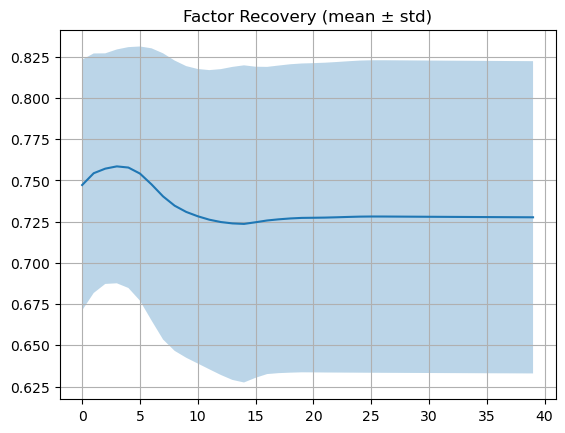

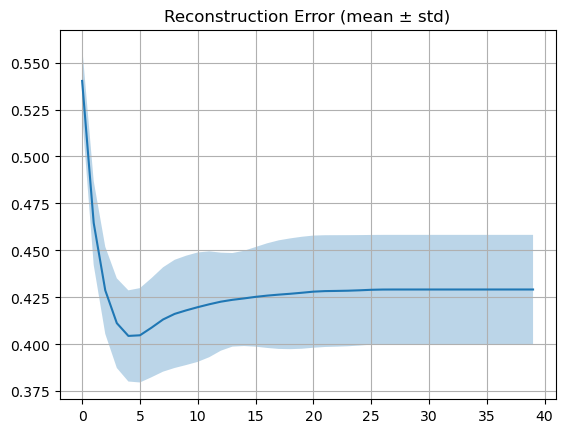

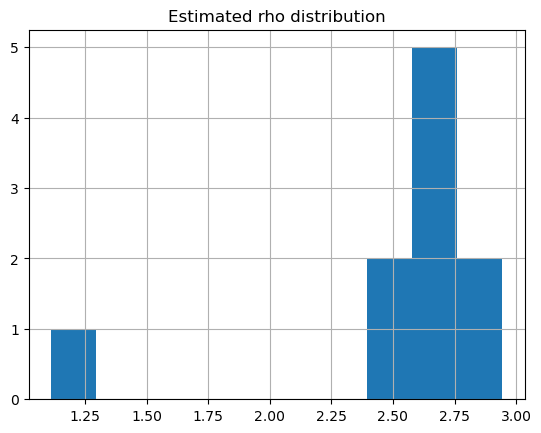

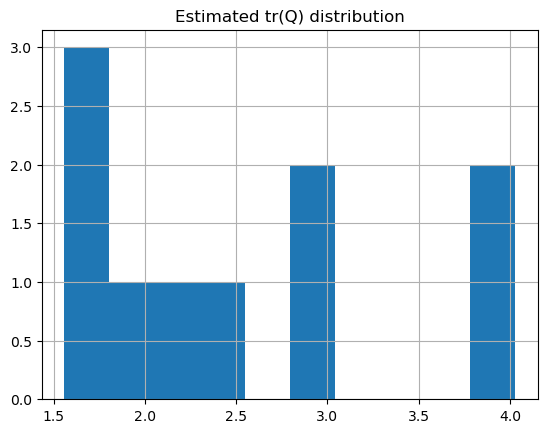

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ============================================================
# 1. DATA GENERATION
# ============================================================

def simulate_ou_dfa(seed,
    n_subjects=10,
    T_list=(5,4,6,5,7,4,5,6,5,5),
    p=20,
    k=5,
    rho_mean=0.05,
    rho_sd=0.03,
    Q_scale=0.3,
    Psi_scale=0.5,
    sparsity=0.7,
):
    rng = np.random.default_rng(seed)

    Lambda = rng.normal(size=(p, k))
    Lambda *= rng.uniform(size=(p, k)) > sparsity
    Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)

    rho_true = np.abs(rng.normal(rho_mean, rho_sd, size=k))
    R = rng.normal(size=(k, k))
    Q_true = Q_scale * (R @ R.T) / k

    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        dt = rng.uniform(0.3, 10.0, size=T - 1)
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = rng.normal(size=k)

        for t in range(1, T):
            A = np.diag(np.exp(-rho_true * dt[t-1]))
            z[t] = A @ z[t-1] + rng.multivariate_normal(np.zeros(k), Q_true)

        Psi_diag = Psi_scale * rng.lognormal(0, 0.5, size=p)
        y = z @ Lambda.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda, rho_true, Q_true, dts_all


# ============================================================
# 2. KALMAN SMOOTHER
# ============================================================

def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m, P = np.zeros(k), np.eye(k)
    m_f, P_f = [], []

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            m = A @ m
            P = A @ P @ A.T + Q

        S = Lambda @ P @ Lambda.T + Psi + 1e-6*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        m_f.append(m)
        P_f.append(P)

    Ez, Ezz, Ezztm1 = [None]*T, [None]*T, [None]*(T-1)
    Ez[-1] = m_f[-1]
    Ezz[-1] = P_f[-1] + np.outer(Ez[-1], Ez[-1])

    for t in reversed(range(T-1)):
        A = np.exp(-rho * dt[t]) * np.eye(k)
        P_pred = A @ P_f[t] @ A.T + Q
        J = P_f[t] @ A.T @ np.linalg.inv(P_pred)

        Ez[t] = m_f[t] + J @ (Ez[t+1] - A @ m_f[t])
        P = P_f[t] + J @ (Ezz[t+1] - P_pred) @ J.T

        Ezz[t] = P + np.outer(Ez[t], Ez[t])
        Ezztm1[t] = J @ Ezz[t+1]

    return Ez, Ezz, Ezztm1


# ============================================================
# 3. EM
# ============================================================

def run_em(Ys, dts_all, k, seed, n_iter=40):
    rng = np.random.default_rng(seed)
    p = Ys[0].shape[1]

    Lambda = rng.normal(size=(p, k))
    Psi = np.eye(p)
    rho = 0.05
    Q = np.eye(k)

    hist_L, hist_mse = [], []

    for _ in range(n_iter):
        Ezs, Ezzs, Ezztm1s = [], [], []

        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz, Ezztm1 = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
            Ezztm1s.append(Ezztm1)

        # updates
        Ezz_sum = sum(Ezz[t] for Ezz in Ezzs for t in range(len(Ezz)))
        Ezy_sum = sum(np.outer(Ezs[s][t], Ys[s][t])
                      for s in range(len(Ys)) for t in range(len(Ys[s])))

        Lambda = np.linalg.solve(Ezz_sum + 1e-6*np.eye(k), Ezy_sum).T

        Psi = np.diag(np.mean([
            (Ys[s][t] - Lambda @ Ezs[s][t])**2
            for s in range(len(Ys))
            for t in range(len(Ys[s]))
        ], axis=0))

        rho = -np.log(np.clip(
            sum(np.trace(Ezztm1[t]) for Ezztm1 in Ezztm1s for t in range(len(Ezztm1))) /
            sum(np.trace(Ezz[t]) for Ezz in Ezzs for t in range(len(Ezz)-1)),
            1e-6, 1-1e-6)) / np.mean(np.concatenate(dts_all))

        Q = np.mean([
            Ezz[t+1] - np.exp(-rho*dts_all[s][t]) * Ezztm1[t].T
            for s,(Ezz,Ezztm1) in enumerate(zip(Ezzs,Ezztm1s))
            for t in range(len(Ezztm1))
        ], axis=0)

        mse = np.mean([
            np.mean((Ys[s] - np.array(Ezs[s]) @ Lambda.T)**2)
            for s in range(len(Ys))
        ])

        hist_L.append(Lambda.copy())
        hist_mse.append(mse)

    return Lambda, rho, Q, hist_L, hist_mse


# ============================================================
# 4. MULTI-RUN EXPERIMENT
# ============================================================

def multi_run_experiment(n_runs=10):
    rec_curves, mse_curves = [], []
    rhos = []
    traces_Q = []

    for seed in range(n_runs):
        Ys, Zs, L_true, rho_true, Q_true, dts = simulate_ou_dfa(seed)
        L, rho, Q, hist_L, hist_mse = run_em(Ys, dts, k=L_true.shape[1], seed=seed)

        rec = []
        for Lh in hist_L:
            R,_ = orthogonal_procrustes(Lh, L_true)
            rec.append(np.corrcoef(L_true.ravel(), (Lh@R).ravel())[0,1])

        rec_curves.append(rec)
        mse_curves.append(hist_mse)
        rhos.append(rho)
        traces_Q.append(np.trace(Q))

    return np.array(rec_curves), np.array(mse_curves), rhos, traces_Q


# ============================================================
# 5. VISUALIZATION
# ============================================================

def plot_reproducibility(rec, mse, rhos, traces_Q):
    x = np.arange(rec.shape[1])

    plt.figure()
    plt.plot(x, rec.mean(0))
    plt.fill_between(x, rec.mean(0)-rec.std(0), rec.mean(0)+rec.std(0), alpha=0.3)
    plt.title("Factor Recovery (mean ± std)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(x, mse.mean(0))
    plt.fill_between(x, mse.mean(0)-mse.std(0), mse.mean(0)+mse.std(0), alpha=0.3)
    plt.title("Reconstruction Error (mean ± std)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.hist(rhos, bins=10)
    plt.title("Estimated rho distribution")
    plt.grid()
    plt.show()

    plt.figure()
    plt.hist(traces_Q, bins=10)
    plt.title("Estimated tr(Q) distribution")
    plt.grid()
    plt.show()


# ============================================================
# 6. MAIN
# ============================================================

if __name__ == "__main__":
    rec, mse, rhos, traces_Q = multi_run_experiment(n_runs=10)
    plot_reproducibility(rec, mse, rhos, traces_Q)


/tmp/ipykernel_2419258/2585157457.py:171: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  g[0] = rng.multivariate_normal(np.zeros(k), P0)


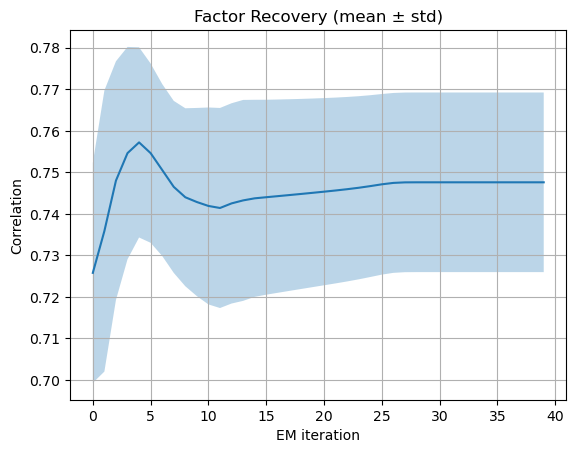

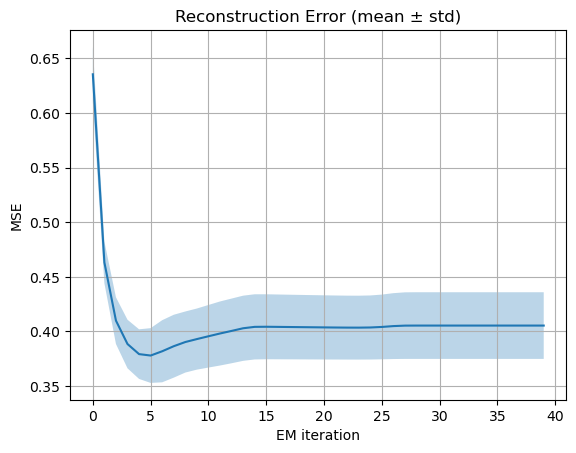

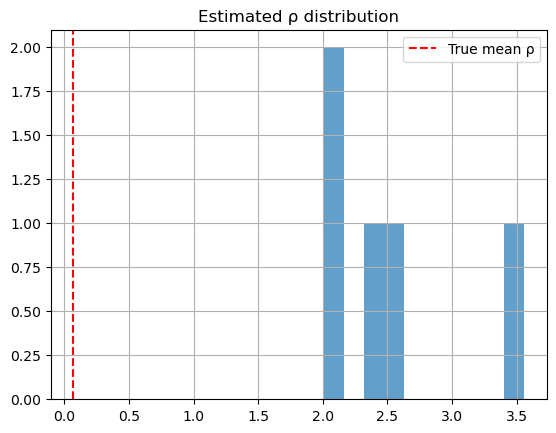

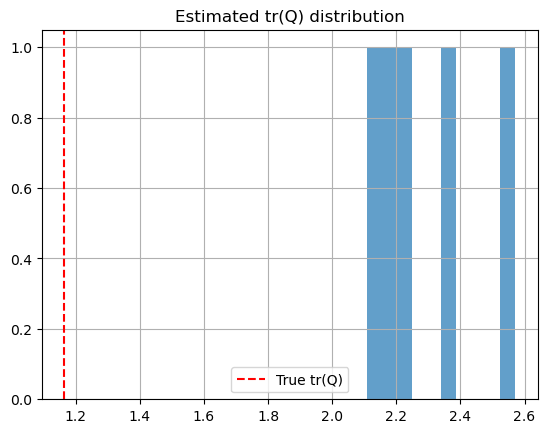

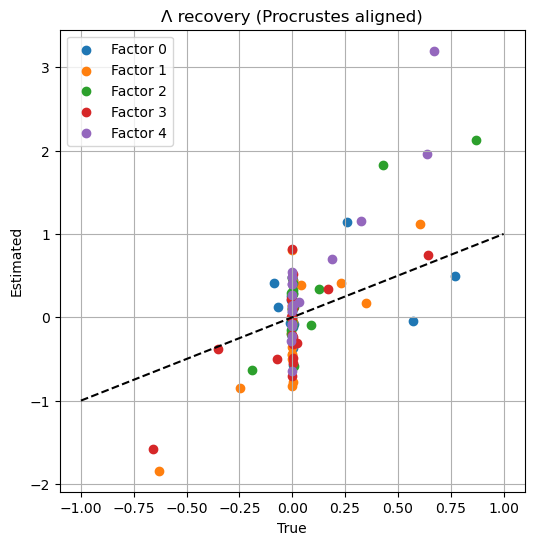

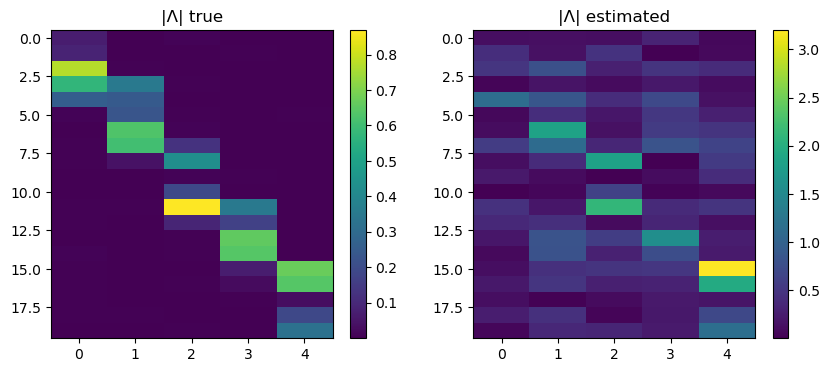

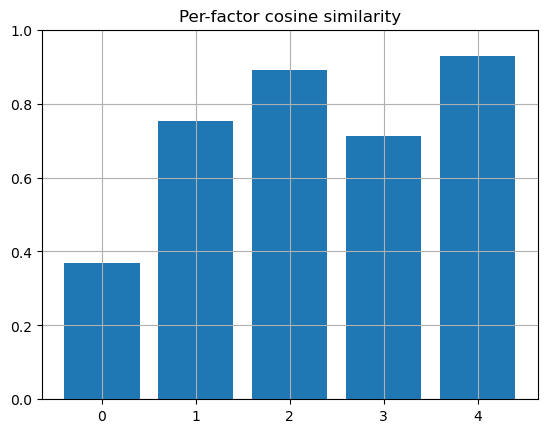

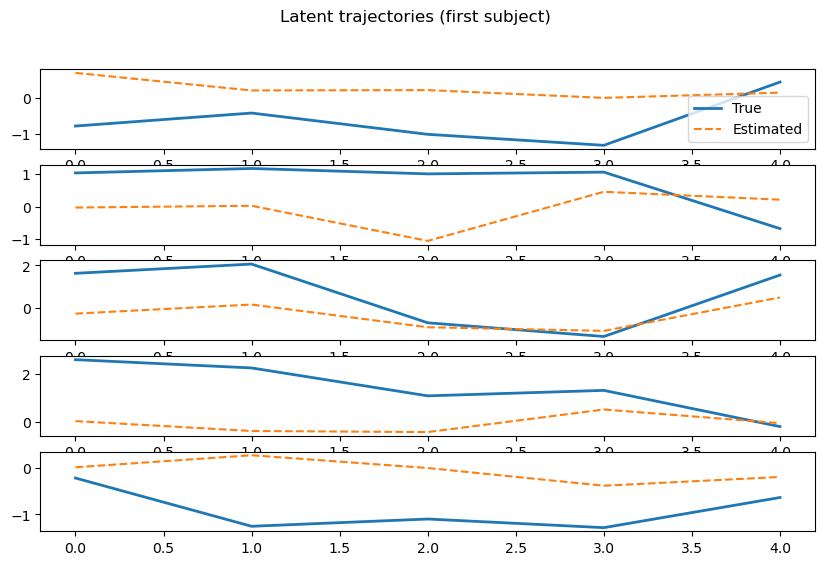

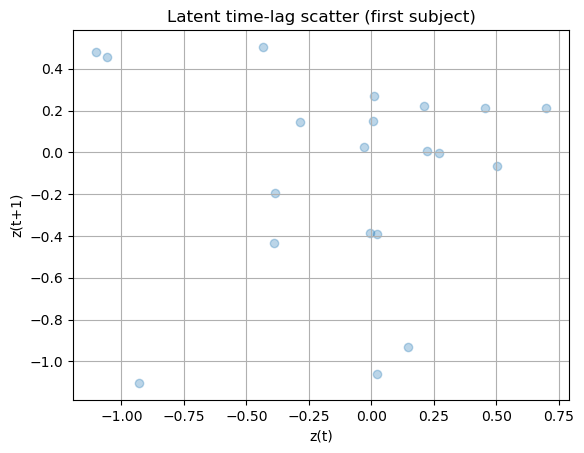

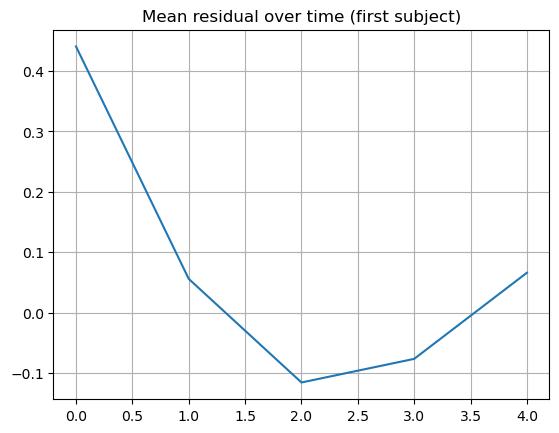

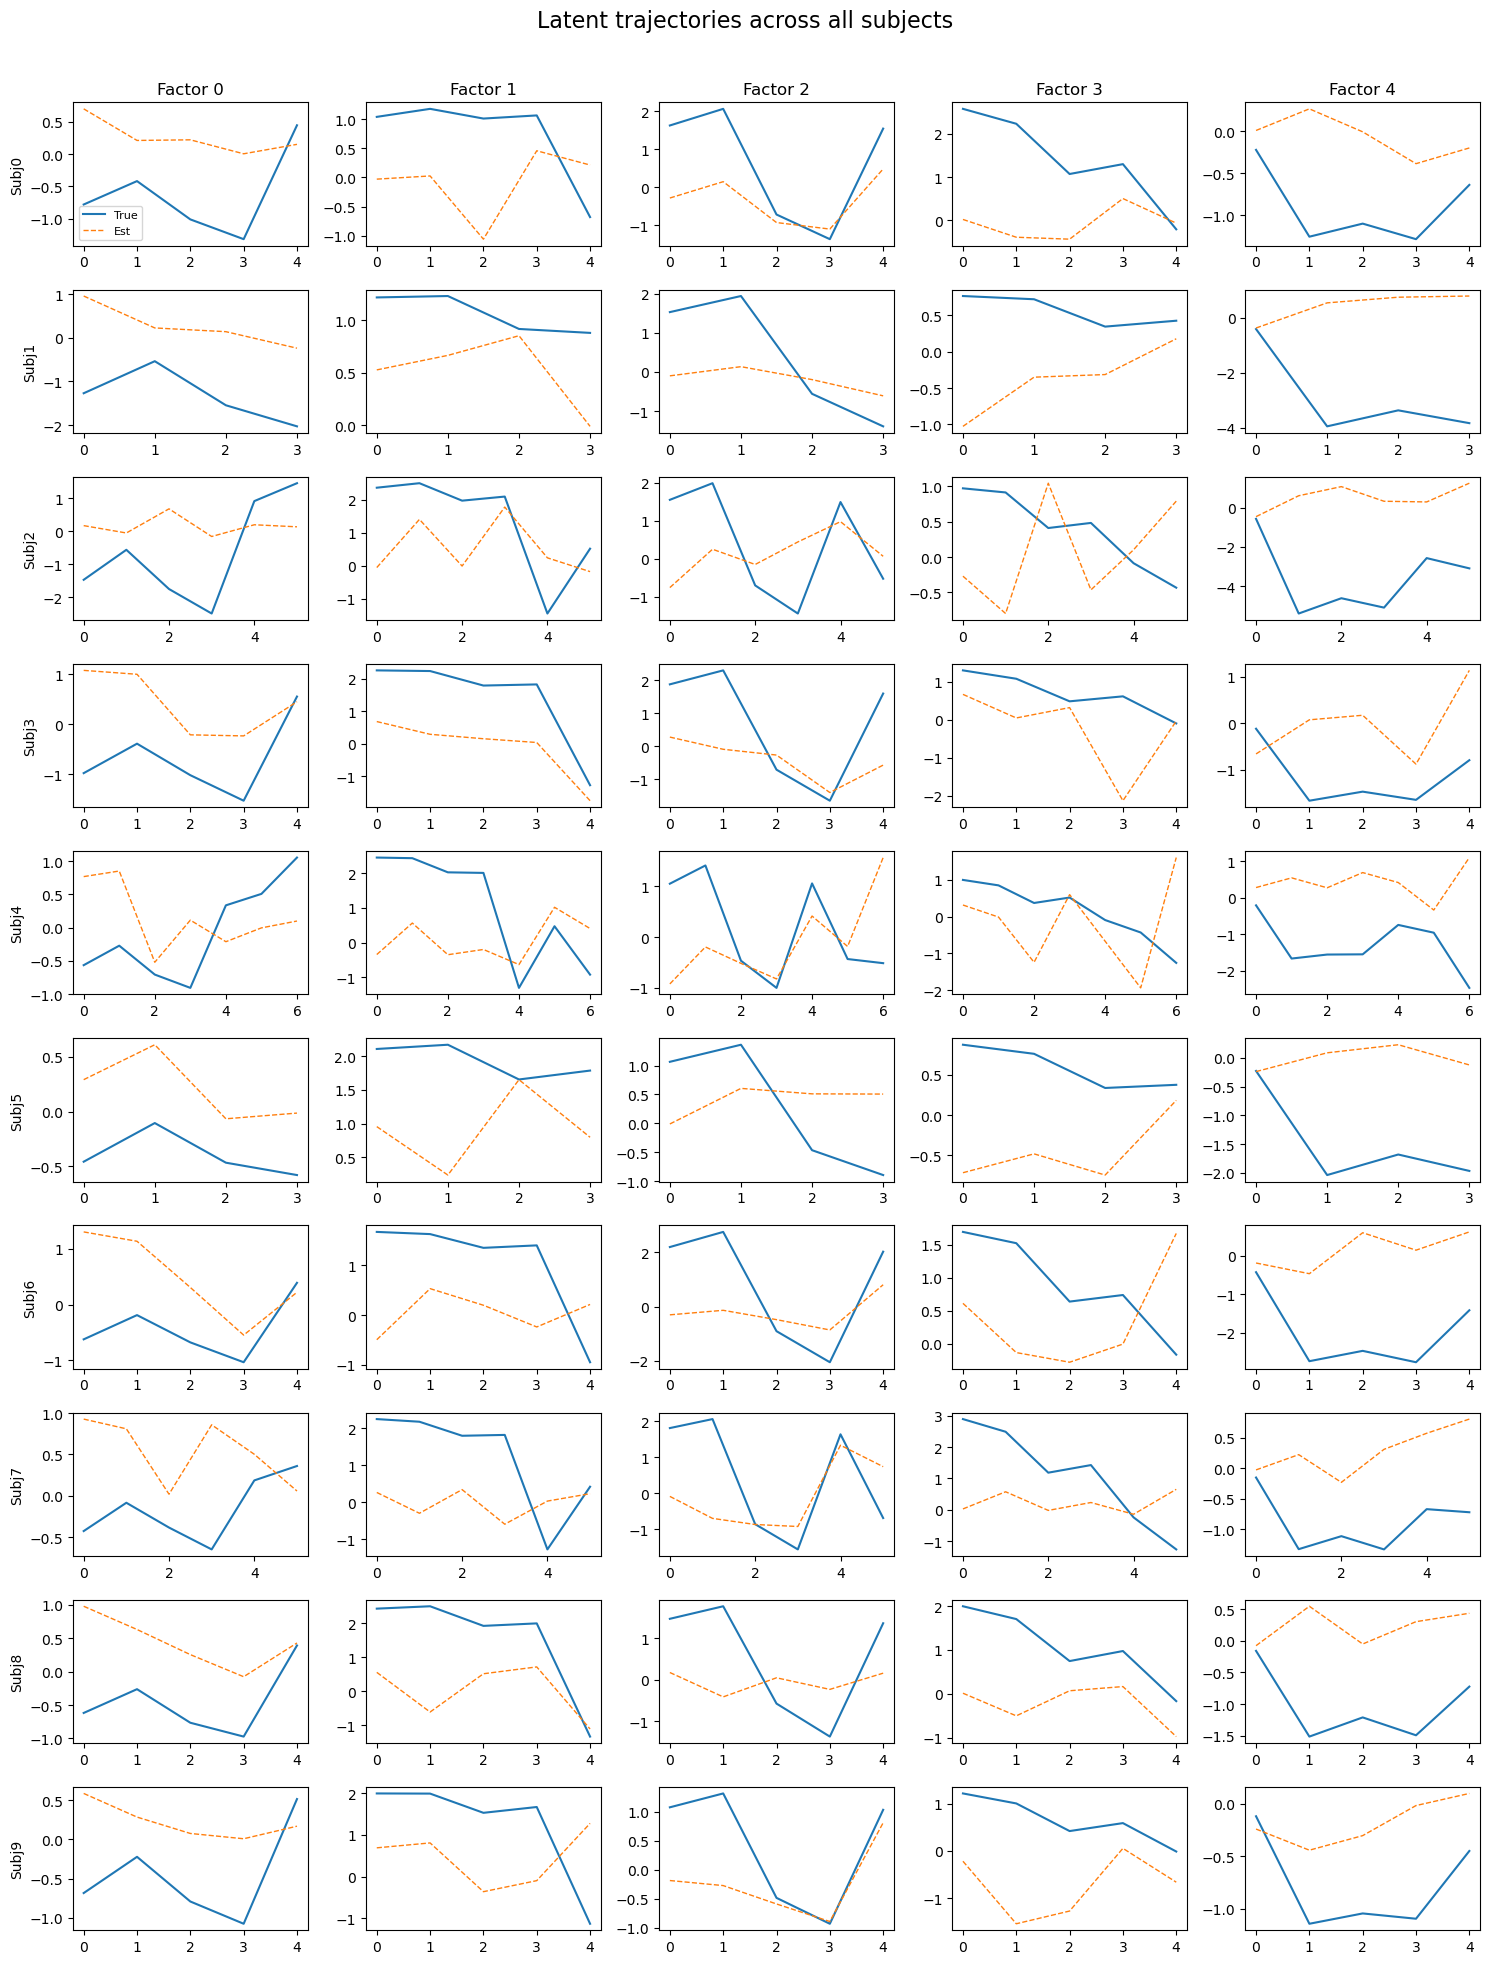

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

# ============================================================
# 1. DATA GENERATION
# ============================================================

def generate_structured_lambda(
    rng,
    p,
    k,
    block_size=None,
    overlap=0,
    loading_scale=2.0,
    noise_scale=0.05
):
    """
    Structured sparse factor loadings.

    Each factor loads strongly on its own block of features,
    weakly (or not at all) elsewhere.

    Parameters
    ----------
    block_size : int or None
        Number of features per factor block.
        Default: p // k
    overlap : int
        Number of overlapping features between neighboring factors.
    loading_scale : float
        Magnitude of true signal loadings.
    noise_scale : float
        Small noise added everywhere to avoid exact zeros.

    Returns
    -------
    Lambda : (p, k)
    """
    if block_size is None:
        block_size = p // k

    Lambda = noise_scale * rng.normal(size=(p, k))

    for j in range(k):
        start = j * block_size
        end = start + block_size

        # Add overlap
        start = max(0, start - overlap)
        end = min(p, end + overlap)

        Lambda[start:end, j] += loading_scale * rng.normal(size=(end - start))

    # Normalize columns for identifiability
    Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)

    return Lambda


def ou_transition(z_prev, rho, Q, dt, rng):
    A = np.diag(np.exp(-rho * dt))

    # OU-consistent process noise
    D = (1.0 - np.exp(-2 * rho * dt)) / (2 * rho + 1e-8)
    Q_dt = np.diag(D) @ Q @ np.diag(D)

    return A @ z_prev + rng.multivariate_normal(np.zeros(len(rho)), Q_dt)



# def simulate_ou_dfa(seed,
#                     n_subjects=10,
#                     T_list=(5,4,6,5,7,4,5,6,5,5),
#                     p=20,
#                     k=5,
#                     rho_mean=0.05,
#                     rho_sd=0.03,
#                     Q_scale=0.3,
#                     Psi_scale=0.5,
#                     sparsity=0.7):
#     rng = np.random.default_rng(seed)

#     # Factor loadings
#     # Lambda = rng.normal(size=(p, k))
#     # Lambda *= rng.uniform(size=(p, k)) > sparsity
#     # Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)
#     Lambda = generate_structured_lambda(
#         rng,
#         p=p,
#         k=k,
#         block_size=p // k,
#         overlap=1,          # try 0–2
#         loading_scale=3.0,  # increase to make recovery harder
#         noise_scale=0.02
#     )

#     # OU parameters
#     rho_true = np.abs(rng.normal(rho_mean, rho_sd, size=k))
#     R = rng.normal(size=(k, k))
#     Q_true = Q_scale * (R @ R.T) / k

#     Ys, Zs, dts_all = [], [], []

#     for T in T_list:
#         dt = rng.uniform(0.3, 10.0, size=T - 1)
#         dts_all.append(dt)

#         z = np.zeros((T, k))
#         z[0] = rng.normal(size=k)

#         for t in range(1, T):
#             A = np.diag(np.exp(-rho_true * dt[t-1]))
#             # z[t] = A @ z[t-1] + rng.multivariate_normal(np.zeros(k), Q_true)
#             z[t] = ou_transition(z[t-1], rho_true, Q_true, dt[t-1], rng)

#         Psi_diag = Psi_scale * rng.lognormal(0, 0.5, size=p)
#         y = z @ Lambda.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

#         Ys.append(y)
#         Zs.append(z)

#     return Ys, Zs, Lambda, rho_true, Q_true, dts_all

import numpy as np

def simulate_ou_dfa(seed,
                    n_subjects=10,
                    T_list=(5,4,6,5,7,4,5,6,5,5),
                    p=20,
                    k=5,
                    rho_mean=0.05,
                    rho_sd=0.03,
                    Q_scale=0.3,
                    Psi_scale=0.5,
                    sparsity=0.7):
    rng = np.random.default_rng(seed)

    # ============================================================
    # 1. Structured, informative, sparse factor loadings
    # ============================================================
    Lambda = generate_structured_lambda(
        rng,
        p=p,
        k=k,
        block_size=p // k,
        overlap=1,
        loading_scale=3.0,
        noise_scale=0.02
    )
    Lambda /= np.linalg.norm(Lambda, axis=0, keepdims=True)

    # ============================================================
    # 2. OU parameters (shared across all subjects)
    # ============================================================
    rho_true = np.abs(rng.normal(rho_mean, rho_sd, size=k))

    R = rng.normal(size=(k, k))
    Q_true = Q_scale * (R @ R.T) / k

    # ============================================================
    # 3. Generate ONE shared global OU latent trajectory
    # ============================================================
    T_global = max(T_list)
    dt_global = rng.uniform(0.3, 10.0, size=T_global - 1)

    g = np.zeros((T_global, k))

    # Stationary initialization
    P0 = Q_true / (2 * rho_true[:, None] + 1e-8)
    g[0] = rng.multivariate_normal(np.zeros(k), P0)

    for t in range(1, T_global):
        dt = dt_global[t - 1]

        A = np.diag(np.exp(-rho_true * dt))
        D = (1 - np.exp(-2 * rho_true * dt)) / (2 * rho_true + 1e-8)
        Qdt = np.diag(D) @ Q_true @ np.diag(D)

        g[t] = A @ g[t - 1] + rng.multivariate_normal(np.zeros(k), Qdt)

    # Normalize global trend (prevents scale pathologies)
    g /= np.std(g, axis=0, keepdims=True) + 1e-6

    # ============================================================
    # 4. Subject-specific deformation + observations
    # ============================================================
    Ys, Zs, dts_all = [], [], []

    for T in T_list:
        # Subject-specific latent deformation
        scale = np.exp(rng.normal(0, 0.4, size=k))
        z = g[:T] * scale

        # Small idiosyncratic noise (preserves shared trend)
        z += rng.normal(0, 0.05, size=z.shape)

        # Observation noise
        Psi_diag = Psi_scale * rng.lognormal(0, 0.25, size=p)
        y = z @ Lambda.T + rng.normal(0, np.sqrt(Psi_diag), size=(T, p))

        Ys.append(y)
        Zs.append(z)
        dts_all.append(dt_global[:T-1])

    # ============================================================
    # 5. Return (API unchanged)
    # ============================================================
    return Ys, Zs, Lambda, rho_true, Q_true, dts_all


# ============================================================
# 2. KALMAN SMOOTHER
# ============================================================

def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]
    m, P = np.zeros(k), np.eye(k)
    m_f, P_f = [], []

    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            m = A @ m
            P = A @ P @ A.T + Q

        S = Lambda @ P @ Lambda.T + Psi + 1e-6*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P

        m_f.append(m)
        P_f.append(P)

    Ez, Ezz, Ezztm1 = [None]*T, [None]*T, [None]*(T-1)
    Ez[-1] = m_f[-1]
    Ezz[-1] = P_f[-1] + np.outer(Ez[-1], Ez[-1])

    for t in reversed(range(T-1)):
        A = np.exp(-rho * dt[t]) * np.eye(k)
        P_pred = A @ P_f[t] @ A.T + Q
        J = P_f[t] @ A.T @ np.linalg.inv(P_pred)

        Ez[t] = m_f[t] + J @ (Ez[t+1] - A @ m_f[t])
        P = P_f[t] + J @ (Ezz[t+1] - P_pred) @ J.T

        Ezz[t] = P + np.outer(Ez[t], Ez[t])
        Ezztm1[t] = J @ Ezz[t+1]

    return Ez, Ezz, Ezztm1

# ============================================================
# 3. EM STEP
# ============================================================

def run_em(Ys, dts_all, k, seed, n_iter=40):
    rng = np.random.default_rng(seed)
    p = Ys[0].shape[1]

    Lambda = rng.normal(size=(p, k))
    Psi = np.eye(p)
    rho = 0.05
    Q = np.eye(k)

    hist_L, hist_mse = [], []

    for _ in range(n_iter):
        Ezs, Ezzs, Ezztm1s = [], [], []

        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz, Ezztm1 = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
            Ezztm1s.append(Ezztm1)

        # Lambda update
        Ezz_sum = sum(Ezz[t] for Ezz in Ezzs for t in range(len(Ezz)))
        Ezy_sum = sum(np.outer(Ezs[s][t], Ys[s][t])
                      for s in range(len(Ys)) for t in range(len(Ys[s])))

        Lambda = np.linalg.solve(Ezz_sum + 1e-6*np.eye(k), Ezy_sum).T

        # Psi update
        Psi = np.diag(np.mean([
            (Ys[s][t] - Lambda @ Ezs[s][t])**2
            for s in range(len(Ys)) for t in range(len(Ys[s]))
        ], axis=0))

        # rho update
        rho = -np.log(np.clip(
            sum(np.trace(Ezztm1[t]) for Ezztm1 in Ezztm1s for t in range(len(Ezztm1))) /
            sum(np.trace(Ezz[t]) for Ezz in Ezzs for t in range(len(Ezz)-1)),
            1e-6, 1-1e-6)) / np.mean(np.concatenate(dts_all))

        # Q update
        Q = np.mean([
            Ezz[t+1] - np.exp(-rho*dts_all[s][t]) * Ezztm1[t].T
            for s,(Ezz,Ezztm1) in enumerate(zip(Ezzs,Ezztm1s))
            for t in range(len(Ezztm1))
        ], axis=0)

        # reconstruction error
        mse = np.mean([
            np.mean((Ys[s] - np.array(Ezs[s]) @ Lambda.T)**2)
            for s in range(len(Ys))
        ])

        hist_L.append(Lambda.copy())
        hist_mse.append(mse)

    return Lambda, rho, Q, hist_L, hist_mse, Ezs

# ============================================================
# 4. MULTI-RUN EXPERIMENT
# ============================================================

def multi_run_experiment(n_runs=5):
    rec_curves, mse_curves = [], []
    rhos, traces_Q = [], []

    for seed in range(n_runs):
        Ys, Zs, L_true, rho_true, Q_true, dts = simulate_ou_dfa(seed)
        Lambda_est, rho_est, Q_est, hist_L, hist_mse, Ezs = run_em(Ys, dts, k=L_true.shape[1], seed=seed)

        # factor recovery
        rec = []
        for Lh in hist_L:
            R,_ = orthogonal_procrustes(Lh, L_true)
            rec.append(np.corrcoef(L_true.ravel(), (Lh@R).ravel())[0,1])

        rec_curves.append(rec)
        mse_curves.append(hist_mse)
        rhos.append(rho_est)
        traces_Q.append(np.trace(Q_est))

    return np.array(rec_curves), np.array(mse_curves), rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys

# ============================================================
# 5. VISUALIZATION
# ============================================================


def visualize_all(rec_curves, mse_curves, rhos, traces_Q, Lambda_true, Lambda_est, rho_true, Q_true, Z_true, Z_est, Y_true, Y_hat):
    n_runs, n_iter = rec_curves.shape
    x = np.arange(n_iter)

    # ----------------- 1. Global convergence -----------------
    plt.figure()
    plt.plot(x, rec_curves.mean(0))
    plt.fill_between(x, rec_curves.mean(0)-rec_curves.std(0), rec_curves.mean(0)+rec_curves.std(0), alpha=0.3)
    plt.title("Factor Recovery (mean ± std)")
    plt.xlabel("EM iteration")
    plt.ylabel("Correlation")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(x, mse_curves.mean(0))
    plt.fill_between(x, mse_curves.mean(0)-mse_curves.std(0), mse_curves.mean(0)+mse_curves.std(0), alpha=0.3)
    plt.title("Reconstruction Error (mean ± std)")
    plt.xlabel("EM iteration")
    plt.ylabel("MSE")
    plt.grid()
    plt.show()

    # ----------------- 2. Parameter identifiability -----------------
    plt.figure()
    plt.hist(rhos, bins=10, alpha=0.7)
    plt.axvline(rho_true.mean(), color='r', linestyle='--', label="True mean ρ")
    plt.title("Estimated ρ distribution")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure()
    plt.hist(traces_Q, bins=10, alpha=0.7)
    plt.axvline(np.trace(Q_true), color='r', linestyle='--', label="True tr(Q)")
    plt.title("Estimated tr(Q) distribution")
    plt.legend()
    plt.grid()
    plt.show()

    # ----------------- 3. Factor loadings -----------------
    R,_ = orthogonal_procrustes(Lambda_est, Lambda_true)
    L_align = Lambda_est @ R

    plt.figure(figsize=(6,6))
    for kf in range(Lambda_true.shape[1]):
        plt.scatter(Lambda_true[:,kf], L_align[:,kf], label=f"Factor {kf}")
    plt.plot([-1,1],[-1,1],'k--')
    plt.legend()
    plt.title("Λ recovery (Procrustes aligned)")
    plt.xlabel("True")
    plt.ylabel("Estimated")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(np.abs(Lambda_true), aspect='auto')
    plt.title("|Λ| true")
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.imshow(np.abs(L_align), aspect='auto')
    plt.title("|Λ| estimated")
    plt.colorbar()
    plt.show()

    cos_sim = np.sum(Lambda_true*L_align,axis=0)/(np.linalg.norm(Lambda_true,axis=0)*np.linalg.norm(L_align,axis=0))
    plt.figure()
    plt.bar(range(len(cos_sim)), cos_sim)
    plt.title("Per-factor cosine similarity")
    plt.ylim(0,1)
    plt.grid()
    plt.show()

    # ----------------- 4. Latent trajectories (first subject) -----------------
    Z_true_arr = np.array(Z_true[0])
    Z_est_arr = np.array(Z_est[0])
    Y_true_arr = np.array(Y_true[0])
    Y_hat_arr = np.array(Y_hat[0])
    T, k = Z_true_arr.shape

    plt.figure(figsize=(10,6))
    for i in range(k):
        plt.subplot(k,1,i+1)
        plt.plot(Z_true_arr[:,i], label="True", linewidth=2)
        plt.plot(Z_est_arr[:,i], '--', label="Estimated")
        if i==0:
            plt.legend()
    plt.suptitle("Latent trajectories (first subject)")
    plt.show()

    plt.figure()
    plt.scatter(Z_est_arr[:-1].ravel(), Z_est_arr[1:].ravel(), alpha=0.3)
    plt.title("Latent time-lag scatter (first subject)")
    plt.xlabel("z(t)")
    plt.ylabel("z(t+1)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot((Y_true_arr-Y_hat_arr).mean(1))
    plt.title("Mean residual over time (first subject)")
    plt.grid()
    plt.show()

    # ----------------- 5. Latent trajectories (all subjects grid) -----------------
    n_subjects = len(Z_true)
    k = Z_true_arr.shape[1]
    plt.figure(figsize=(15, n_subjects*2))
    for s in range(n_subjects):
        Zt = np.array(Z_true[s])
        Ze = np.array(Z_est[s])
        T = Zt.shape[0]
        for f in range(k):
            plt.subplot(n_subjects, k, s*k + f + 1)
            plt.plot(range(T), Zt[:,f], label="True", linewidth=1.5)
            plt.plot(range(T), Ze[:,f], '--', label="Est", linewidth=1)
            if s==0 and f==0:
                plt.legend(fontsize=8)
            if f==0:
                plt.ylabel(f"Subj{s}")
            if s==0:
                plt.title(f"Factor {f}")
    plt.suptitle("Latent trajectories across all subjects", fontsize=16)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()

# ============================================================
# 6. MAIN
# ============================================================

if __name__=="__main__":
    rec_curves, mse_curves, rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys = multi_run_experiment(n_runs=5)
    Y_hat = [np.array(Ez) @ Lambda_est.T for Ez in Ezs]

    visualize_all(rec_curves, mse_curves, rhos, traces_Q, L_true, Lambda_est, rho_true, Q_true, Zs, Ezs, Ys, Y_hat)
